In [1]:
import mlx.core as mx
import numpy as np
import time
import matplotlib.pyplot as plt
import mlx
import scipy
print(mx.metal.is_available())

True


In [2]:
from numba import jit
from numba.experimental import jitclass
import numba


In [3]:
start=time.time()
RESOLUTION = 2**14
def mxprodsine(x: mx.array,func: mx.array,fpow: int):
    NUMINPUT = x.shape[0]
    NUMDIM = x.shape[1]
    NUMFREQ = func.shape[2]
    print(x.dtype,func.dtype)            
    mult_out = (x*func/RESOLUTION*2)*np.pi
    mult_out = (mx.cos(mult_out)+1j*mx.sin(mult_out))*fpow
    prod_out = mx.zeros((NUMINPUT,NUMFREQ),dtype=mx.complex64)
    prod_out = mult_out[:,0,:]*mult_out[:,1,:]
    mult_out = prod_out.sum(1)
    return mult_out

In [4]:
@jit(nopython=True)
def prodsine(x,func,fpow):
    NUMINPUT = x.shape[0]
    NUMDIM = x.shape[1]
    NUMFREQ = func.shape[2]
    mult_out = (x*func/RESOLUTION*2)*np.pi
    mult_out = (np.cos(mult_out)+1j*np.sin(mult_out))*fpow
    prod_out = np.zeros((NUMINPUT,NUMFREQ),dtype='complex64')
    prod_out = mult_out[:,0,:]*mult_out[:,1,:]
    mult_out = prod_out.sum(1)
    return mult_out

In [5]:
np.random.seed=42
mx.random.seed=42
NUMDIM=2
SPARFREQ = 2**11
MAXPOW = 2**4
#TrueFreq = mx.random.randint(low=0,high=RESOLUTION,shape=[1,NUMDIM,SPARFREQ],dtype=mx.int32)
TrueFreq = np.random.randint(0,RESOLUTION,(1,NUMDIM,SPARFREQ))
#TruePow = mx.random.randint(low=1,high=MAXPOW,shape=[SPARFREQ],dtype=mx.int32)
TruePow = (np.random.randint(1,1*MAXPOW,(SPARFREQ))-0*MAXPOW)
print(TrueFreq)
print(TruePow)
print(TrueFreq.shape)
print(np.array(TrueFreq))
print(np.array(TruePow))

[[[ 3005   130  6863 ... 10905  4137 15383]
  [15376 10650  3781 ...  4629  9869 12449]]]
[15 10  9 ...  4 12  3]
(1, 2, 2048)
[[[ 3005   130  6863 ... 10905  4137 15383]
  [15376 10650  3781 ...  4629  9869 12449]]]
[15 10  9 ...  4 12  3]


In [6]:
firstarray = np.zeros((NUMDIM*2*RESOLUTION,NUMDIM,1))
print(firstarray.shape)
firstarray[:RESOLUTION,0,0]=np.arange(RESOLUTION)
firstarray[RESOLUTION:2*RESOLUTION,1,0]=np.arange(RESOLUTION)
firstarray[2*RESOLUTION:3*RESOLUTION,1,0]=np.arange(RESOLUTION)
firstarray[2*RESOLUTION:3*RESOLUTION,0,0]=np.arange(RESOLUTION)
firstarray[3*RESOLUTION:4*RESOLUTION,1,0]=np.arange(RESOLUTION)
firstarray[3*RESOLUTION:4*RESOLUTION,0,0]=RESOLUTION-np.arange(RESOLUTION)
firstarray[3*RESOLUTION,0,0]=0
print((firstarray[:RESOLUTION*1,:,:]).T)

(65536, 2, 1)
[[[0.0000e+00 1.0000e+00 2.0000e+00 ... 1.6381e+04 1.6382e+04 1.6383e+04]
  [0.0000e+00 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]]]


In [7]:
output = mx.zeros([4*RESOLUTION],dtype=mx.complex64)
DIVISION=2**3
STEP = int(RESOLUTION/DIVISION)
print(STEP,DIVISION)
for dd in range(4*DIVISION):
    output[dd*STEP:(dd+1)*STEP] = prodsine(firstarray[dd*STEP:(dd+1)*STEP,:,:],TrueFreq,TruePow)

2048 8


In [8]:
print(output.shape)
#print(np.array(output))
print(np.max(np.abs(np.array(output))))

(65536,)
170956.0


In [9]:
fout1 = mx.fft.fft(output[:RESOLUTION])/RESOLUTION
fout2 = mx.fft.fft(output[RESOLUTION:2*RESOLUTION])/RESOLUTION
fout3 = mx.fft.fft(output[2*RESOLUTION:3*RESOLUTION])/RESOLUTION
fout4 = mx.fft.fft(output[3*RESOLUTION:4*RESOLUTION])/RESOLUTION
print(type(fout1))
print(fout1.shape)
print(fout2.shape)
print(fout3.shape)
print(fout4.shape)
print(time.time()-start)

<class 'mlx.core.array'>
(16384,)
(16384,)
(16384,)
(16384,)
5.585395812988281


In [10]:
def nonzero_base(a: mx.array):
    #inda = mx.arange(a.shape[0])
    maskeda = mx.multiply(a,(a!=0).astype(mx.int8))
    # this is for 1-d
    sindices = mx.argsort(maskeda)
    lind = mx.argmin(a.shape[0]-maskeda)
    slind = mx.argmax(sindices==lind)
    grange = mx.arange(slind,a.shape[0])
    #print('the smallest lowest index ',slind,sindices,lind,maskeda,grange)
    return sindices[grange]
def nonzero_imp(a: mx.array):
    inda = mx.arange(a.shape[0])
    tc = (1-a).sum()
    #print(tc,a.shape[0])
    #maskeda = mx.multiply(inda,(a!=0).astype(mx.uint8))    
    maskeda = mx.multiply(inda,a)        
    #print(mx.topk(maskeda,a.shape[0]-tc),maskeda)
    return mx.topk(maskeda,a.shape[0]-tc)
def nonzero_1d(a: mx.array):
    a = (a!=0).astype(mx.uint8)
    N = a.shape[0]
    return nonzero_imp(a.flatten())
def nonzero_2d(a: mx.array):
    a = (a!=0).astype(mx.uint8)
    N = a.shape[0]
    M = a.shape[1]
    #print(a.shape)
    #print('the base ',nonzero_base(a.flatten()))
    p1,p2 = mx.divmod(nonzero_imp(a.flatten()),M)
    return mx.stack((p1,p2))
def nonzero_3d(a: mx.array):
    a = (a!=0).astype(mx.uint8)
    N = a.shape[0]
    M = a.shape[1]
    Q = a.shape[2]    
    #print(a.shape)
    #print('the base ',nonzero_base(a.flatten()))
    p1,p2 = mx.divmod(nonzero_base(a.flatten()),M)
    p2,p3 = mx.divmod(p2,Q)
    return mx.stack((p1,p2,p3))

In [11]:
nonzero_1d(mx.real((fout1)) > 0.01)

array([11, 27, 42, ..., 16366, 16367, 16375], dtype=int32)

In [12]:
#d1arr = mx.arange(fout1.shape[0]) 
#d2arr = mx.arange(fout2.shape[0])
#print(np.argwhere(np.real(np.array(fout1)) > 0.01).shape)
d1arr = nonzero_1d(mx.real((fout1)) > 0.01)
d2arr = nonzero_1d(mx.real((fout2)) > 0.01)
counter=len(d1arr)
counter2=len(d2arr)
print(counter,counter2)

1927 1927


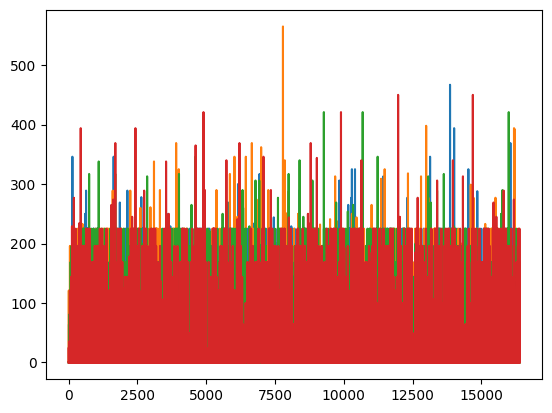

In [13]:
plt.plot(np.real(fout1))
plt.plot(np.real(fout2))
plt.plot(np.real(fout3))
plt.plot(np.real(fout4))

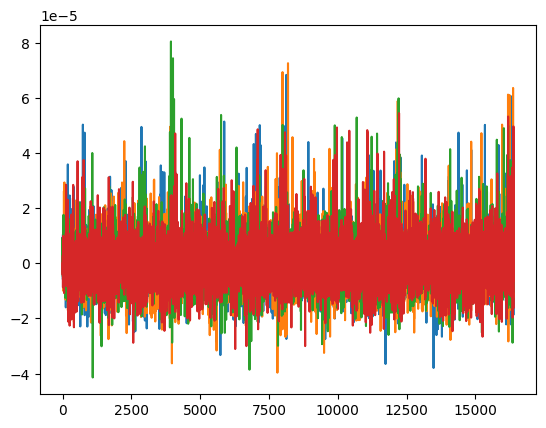

In [14]:
plt.plot(np.imag(fout1))
plt.plot(np.imag(fout2))
plt.plot(np.imag(fout3))
plt.plot(np.imag(fout4))

In [15]:
print(d1arr.flatten())
d11,d22 = mx.meshgrid(d1arr.flatten(), d2arr.flatten())
d12 = mx.remainder(mx.add(d11,d22),RESOLUTION)
d21 = mx.remainder(mx.add(-d11,d22)+RESOLUTION,RESOLUTION)
#print(d12)
print(d21.shape)
print(d11.shape)
print(d22.shape)

array([11, 27, 42, ..., 16366, 16367, 16375], dtype=int32)
(1927, 1927)
(1927, 1927)
(1927, 1927)


In [16]:
d3arr = nonzero_1d(mx.real((fout3)) > 0.01)
d4arr = nonzero_1d(mx.real((fout4)) > 0.01)
counter3=len(d3arr)
counter4=len(d4arr)

In [17]:
def isin2d(element, test_elements):
    if element.shape[0]*element.shape[1]*len(test_elements)>1000000:
        res = mx.zeros(element.shape,dtype=mx.uint8)
        for ele in mx.arange(element.shape[0]):
            res[ele,:]=mx.any(element.reshape(element.shape[0],element.shape[1],1)[ele,:]==test_elements.reshape(1,-1),axis=1)
        return res
    else:
        return mx.any(element.reshape(element.shape[0],element.shape[1],1)==test_elements.reshape(1,1,-1),axis=2)
def isin1d(element, test_elements):
    return mx.any(element.reshape(element.shape[0],1)==test_elements.reshape(1,-1),axis=1)
def isin3d(element, test_elements):
    return mx.any(element.reshape(element.shape[0],element.shape[1]==element.shape[2],1),test_elements.reshape(1,1,1,-1),axis=3)

In [18]:
#print(d12)
print(type(d12))
print(d12.shape)
#print(d3arr)

<class 'mlx.core.array'>
(1927, 1927)


In [19]:
print(mx.array([[0,2,3],[1,0,0]])==0)
print(mx.array([[0,2,3],[1,0,0]])==mx.array([[0,2,3]]))
print(mx.array([[0,2,3],[1,0,0]])==mx.array([[0],[2]]))
print(mx.array([[0,2,3],[1,0,0]])==mx.array([[0],[2]]))
print(mx.array([[[0],[2],[3]],[[1],[0],[0]]])==mx.array([[[0,2,3]]]))
print(mx.array([[[0],[2],[3]],[[1],[0],[0]]]).shape)
print(mx.array([[[0,2,3]]]).shape)
print(mx.any(mx.array([[[0],[2],[3]],[[1],[0],[0]]])==mx.array([[[0,2,3]]]),axis=2))

array([[True, False, False],
       [False, True, True]], dtype=bool)
array([[True, True, True],
       [False, False, False]], dtype=bool)
array([[True, False, False],
       [False, False, False]], dtype=bool)
array([[True, False, False],
       [False, False, False]], dtype=bool)
array([[[True, False, False],
        [False, True, False],
        [False, False, True]],
       [[False, False, False],
        [True, False, False],
        [True, False, False]]], dtype=bool)
(2, 3, 1)
(1, 1, 3)
array([[True, True, True],
       [False, True, True]], dtype=bool)


In [20]:
print(d12.shape,d3arr.shape)
d12b=isin2d(d12, d3arr)
d21b=isin2d(d21, d4arr)
print(d12b.shape)
print(d21b.shape)

(1927, 1927) (1937,)
(1927, 1927)
(1927, 1927)


In [21]:
#print(np.array(d21b))

In [22]:
counter3=mx.min(mx.array([mx.sum(d12b.astype(mx.uint8)),counter3]))
counter4=mx.min(mx.array([(mx.sum(d21b.astype(mx.uint8))),counter4]))
print(counter3)
print(counter4)

array(1937, dtype=int64)
array(1931, dtype=int64)


we can get the indices from argsort... but is that necessary?

we can get the lowest index from argmax or argmin

then argmax to select the index of that sorted index to find the index of the sorted index that is the first non-zero

then return index array that is up to that index

def nonzero(a: mx.array):
    #a1 = 1-mx.equal(a,0).astype(mx.int32)
    a1 = a!=0
    numdim = len(a.shape)
    tc = a1.sum()
    reslist = [None]*numdim
    ranged = np.arange(numdim)
    for d in ranged:
        #print(d,ranged[np.isin(ranged,d)])
        reslist[d]=mx.zeros([tc],dtype=mx.int32)
        dc = a1.sum(axis=ranged[~np.isin(ranged,d)])
        cc = 0
        for ind in np.arange(a.shape[d]):
            print(ind,dc[0],type(ind))
            print(dc)
            if dc[ind]>0:
                reslist[d][cc:(dc[ind]+cc)]=ind
                cc+=dc[ind]
    return reslist
    

In [23]:
print(d21b&d12b)
print(mx.bitwise_and(d21b,d12b))
print(mx.take(d21b,indices=mx.array([0,3,4]),axis=1))
print(mx.array([1,2,3])!=3)
print(mx.argmax((mx.array([1,2,3])!=3).astype(mx.int8)))
print(mx.argmin((mx.array([1,2,3])!=3).astype(mx.int8)))
print(mx.argsort((mx.array([1,2,3])!=3).astype(mx.int8)))

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
array([[0, 0, 0],
       [1, 0, 0],
       [0, 0, 0],
       ...,
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=uint8)
array([True, True, False], dtype=bool)
array(0, dtype=uint32)
array(2, dtype=uint32)
array([2, 0, 1], dtype=uint32)


In [24]:
print((mx.array([[0,2,3],[1,0,0]])!=0).astype(mx.uint8))
print(nonzero_2d((mx.array([[0,2,3],[1,0,0]])!=0).astype(mx.uint8)))

array([[0, 1, 1],
       [1, 0, 0]], dtype=uint8)
array([[0, 0, 1],
       [1, 2, 0]], dtype=int32)


In [25]:
print((mx.array([[0,2,3],[1,0,0]])).astype(mx.uint8))
print(nonzero_2d((mx.array([[0,2,3],[1,0,0]])).astype(mx.uint8)))

array([[0, 2, 3],
       [1, 0, 0]], dtype=uint8)
array([[0, 0, 1],
       [1, 2, 0]], dtype=int32)


In [26]:
print((mx.array([[0,2,3]])).astype(mx.uint8))
print(nonzero_2d((mx.array([[0,2,3]])).astype(mx.uint8)))

array([[0, 2, 3]], dtype=uint8)
array([[0, 0],
       [1, 2]], dtype=int32)


In [27]:
nonzero_2d(d21b)

array([[0, 0, 0, ..., 1926, 1926, 1926],
       [12, 13, 14, ..., 1901, 1920, 1921]], dtype=int32)

In [52]:
print(np.array(nonzero_2d(d21b)).shape)
print(np.array(nonzero_2d(d21b&d12b)).shape)
uset = nonzero_2d(d21b&d12b)
print(counter,counter4,counter2,counter3)
A=mx.zeros([uset.shape[1],int(counter3+counter4+counter+counter2)],dtype=mx.float16)
B=mx.zeros([int(counter3+counter4+counter+counter2)],dtype=mx.float16)


(2, 439742)
(2, 53627)
1927 array(1931, dtype=int64) 1927 array(1937, dtype=int64)


In [53]:
print(uset)
print(uset.shape)

array([[0, 0, 0, ..., 1926, 1926, 1926],
       [14, 38, 69, ..., 1766, 1808, 1876]], dtype=int32)
(2, 53627)


In [54]:
print(A.shape,B.shape)
print(time.time()-start)

(53627, 7722) (7722,)
95931.6914408207


In [55]:
print(d1arr.shape)
print(d12.shape)
print(d3arr.shape)

(1927,)
(1927, 1927)
(1937,)


In [56]:
d3arr[mx.array([3])]

array([42], dtype=int32)

In [ ]:
counteru=0
#print(TruePow)
#cip = cp.remainder(d1arr[uset[0,:]]+d2arr[uset[1,:]],RESOLUTION).ravel()
#cim = cp.remainder(d2arr[uset[1,:]]-d1arr[uset[0,:]]+RESOLUTION,RESOLUTION).ravel()
#print(" cip is {}\n and cim is {}".format(cip.T,cim.T))
#print("d3 is {}".format(d3arr.T))
#print("d4 is {}".format(d4arr.T))
for i in mx.arange(uset.shape[1]):
    u=uset[:,i]
    #print(" u is {} with type {}".format(u,type(u)))
    #print(" element of d1 is {} with {}".format(d1arr[u[1]],cp.real(fout1)[d1arr[u[1]]]))
    #print(" element of d2 is {} with {}".format(d2arr[u[0]],cp.real(fout2)[d2arr[u[0]]]))    
    A[counteru,u[1]]=1
    #print(u[1])
    #print(d1arr[mx.array(u[1])])
    B[u[1]]=np.real(fout1)[d1arr[u[1]]]
    A[counteru,counter+u[0]]=1
    #print(d2arr[u[0]])
    B[counter+u[0]]=np.real(fout2)[d2arr[u[0]]]
    #print(cip[i],cim[i])    
    #print(cp.searchsorted(d3arr.ravel(), cip[i]))
    c=nonzero_1d(d3arr.flatten()==d12[u[0],u[1]])
    #print(" element of d3 is {} with {} and {}".format(d12[u[0],u[1]],c,cp.real(fout3)[d12[u[0],u[1]]]))
    A[counteru,counter+counter2+c]=1
    B[counter+counter2+c]=np.real(fout3)[d12[u[0],u[1]]]
    c=nonzero_1d(d4arr.flatten()==d21[u[0],u[1]])
    #print(" element of d4 is {} with {} and {}".format(d21[u[0],u[1]],c,cp.real(fout4)[d21[u[0],u[1]]]))    
    A[counteru,counter+counter2+counter3+c]=1
    B[counter+counter2+counter3+c]=np.real(fout4)[d21[u[0],u[1]]]    
    counteru+=1